## Import Data

In [6]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
file = h5py.File('Data/train.h5', 'r')
print("Available Keys: ", list(file.keys()))

dataset_data = file['data']
half_life = dataset_data[:] # RNA Half Life

dataset_label = file['label']
label = dataset_label[:]    # Output Label: Rna Expression Level

dataset_promoter = file['promoter']
promoter = dataset_promoter[:]  # Influencing DNA

# print(data)
file.close()

Available Keys:  ['data', 'geneName', 'label', 'promoter']


In [3]:
promoter_numeric = np.argmax(promoter, axis=-1)
promoter_numeric = promoter_numeric[:10]
print(promoter_numeric.shape)
print(promoter_numeric[0])

(10, 20000)
[1 3 0 ... 0 0 3]


## Plot Data

In [10]:
label.max()

3.2576765184943013

<Axes: >

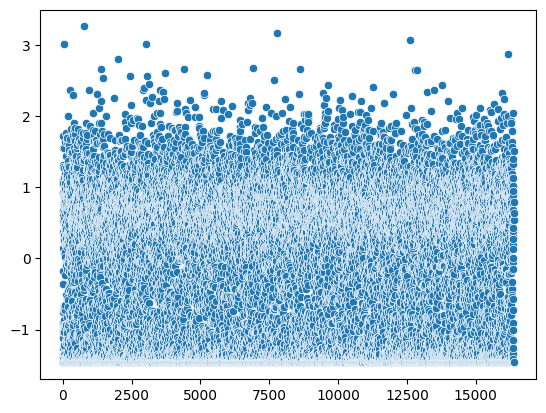

In [ ]:
sns.scatterplot(label)3.2576765184943013

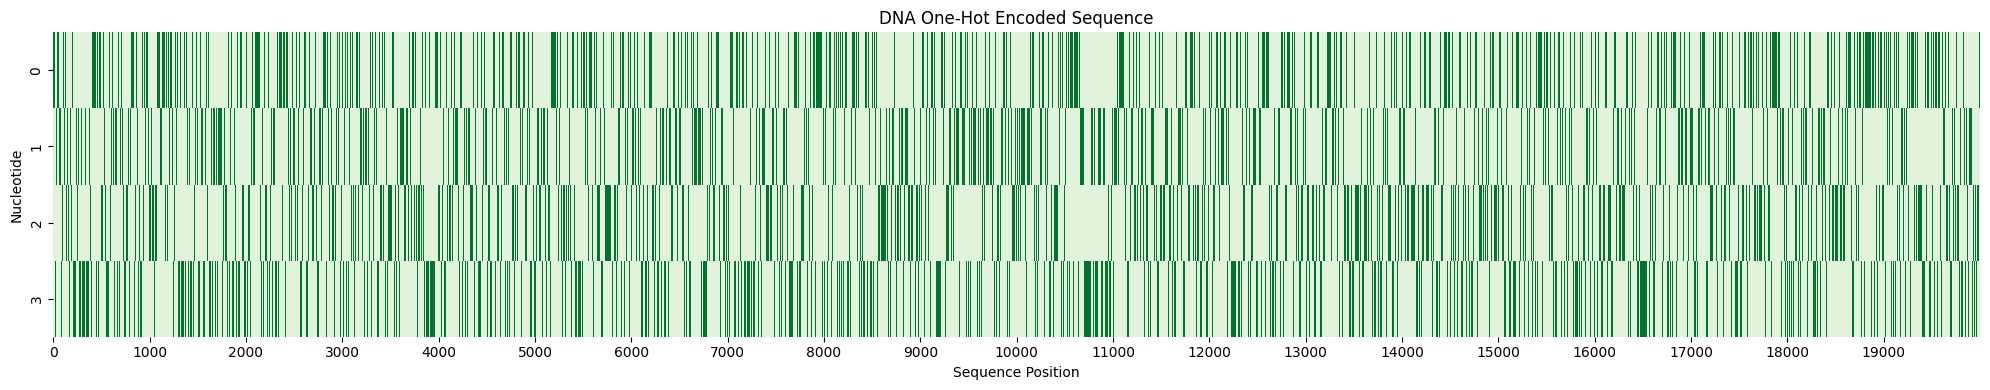

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# Function to one-hot encode a DNA sequence
def one_hot_encode_dna(seq_string):
    # Convert sequence to lowercase and replace non-ACGT with 'N'
    seq_string = seq_string.lower()
    seq_string = ''.join([c if c in 'acgt' else 'n' for c in seq_string])
    seq_array = np.array(list(seq_string))
    
    # Label encode: A, C, G, T, N
    label_encoder = LabelEncoder()
    label_encoder.fit(np.array(['a', 'c', 'g', 't', 'n']))
    int_encoded = label_encoder.transform(seq_array)
    
    # One-hot encode
    onehot_encoder = OneHotEncoder(sparse=False, dtype=int)
    int_encoded = int_encoded.reshape(-1, 1)
    onehot_encoded = onehot_encoder.fit_transform(int_encoded)
    
    # Remove 'N' column if present (last column)
    if 'n' in seq_string:
        onehot_encoded = onehot_encoded[:, :-1]
    return onehot_encoded, label_encoder.classes_[:4]  # Return encoded matrix and labels (A, C, G, T)

# Generate or input a sample DNA sequence
np.random.seed(42)
dna_sequence = ''.join(np.random.choice(['A', 'C', 'G', 'T'], size=100))  # 100-base sequence
# Alternatively, use a specific sequence:
# dna_sequence = "ATCGATCGATCG..."

# One-hot encode the sequence
#one_hot_matrix, nucleotide_labels = one_hot_encode_dna(dna_sequence)

# Create a heatmap resembling GitHub activity chart
plt.figure(figsize=(20, 4))
colormap = sns.color_palette("Greens")
sns.heatmap(
    promoter[0,:,:].T,  # Transpose so nucleotides are rows, positions are columns
    cmap=colormap,  # GitHub-like green gradient
    cbar=False,  # No colorbar needed since it's binary
    xticklabels=1000,  # Show every 10th position
)

# Customize the plot
plt.title("DNA One-Hot Encoded Sequence")
plt.xlabel("Sequence Position")
plt.ylabel("Nucleotide")
plt.tight_layout()

# Save or show the plot
plt.savefig("images/dna_one_hot_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

/tmp/ipykernel_11706/549173592.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd', 4)


KeyboardInterrupt: 

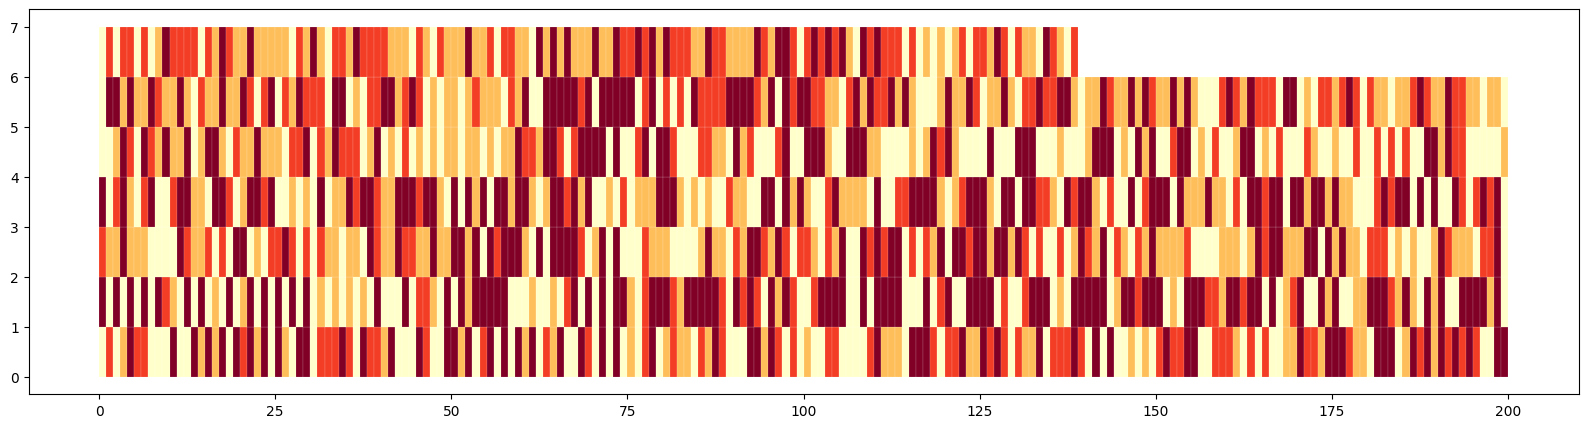

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Convert one-hot encoded promoter to numeric representation (A=0, T=1, C=2, G=3)
numeric_promoter = np.argmax(promoter, axis=2)  # Shape: (16377, 20000)

# Select 10 random sequences (or first 10)
np.random.seed(42)  # For reproducibility
selected_indices = np.random.choice(len(numeric_promoter), 10, replace=False)
subset = numeric_promoter[selected_indices]

# Create colormap (similar to GitHub's activity colors)
cmap = plt.cm.get_cmap('YlOrRd', 4)
colors = [cmap(0.1), cmap(0.4), cmap(0.7), cmap(1.0)]  # Different intensities

# Create plot
plt.figure(figsize=(20, 5))

# Plot each sequence as a line of colored squares
for i, seq in enumerate(subset):
    for pos in range(200):  # Show first 200 positions for clarity
        plt.fill_between([pos, pos+1], [i, i], [i+1, i+1], color=colors[seq[pos]], edgecolor='white', linewidth=0.1)

plt.title('Promoter Sequence Map (GitHub-style)')
plt.xlabel('DNA Position')
plt.ylabel('Sequence Index')
plt.yticks(np.arange(10)+0.5, selected_indices)
plt.xlim(0, 200)  # Only show first 200 positions
plt.gca().invert_yaxis()  # To match GitHub's top-to-bottom ordering

# Create legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], label=nuc)  for i, nuc in enumerate(['A', 'T', 'C', 'G'])]
plt.legend(handles=legend_elements, title='Nucleotides')

plt.tight_layout()
plt.savefig('promoter_map.png', dpi=300)
plt.show()

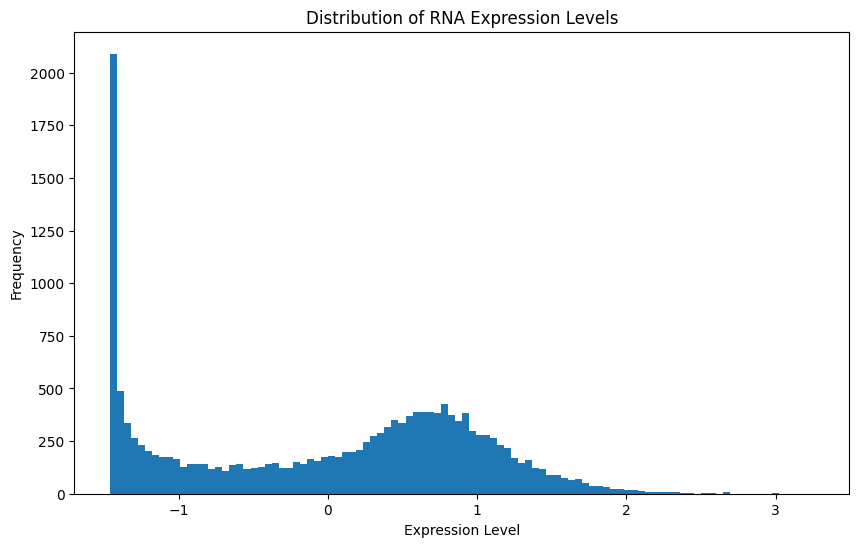

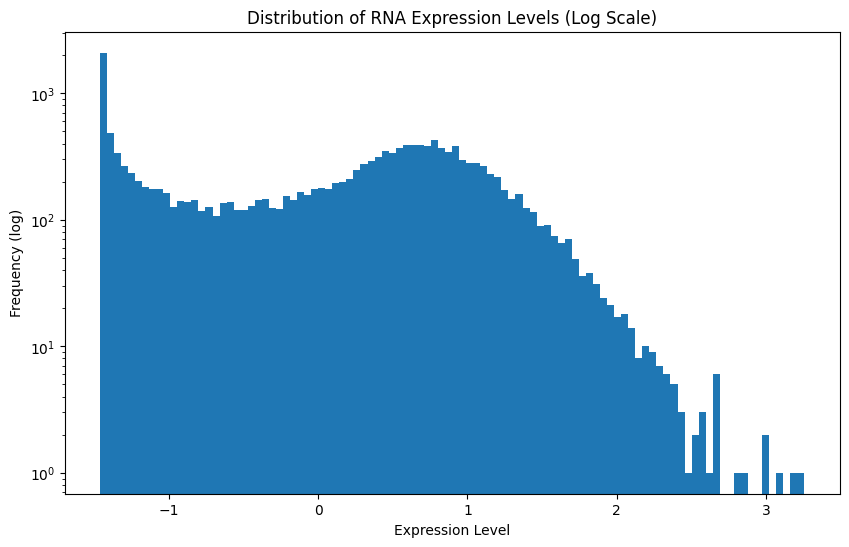

In [6]:
# Assuming 'label' is your expression level numpy array
# label.shape = (16377,)

plt.figure(figsize=(10, 6))
plt.hist(label, bins=100)
plt.title('Distribution of RNA Expression Levels')
plt.xlabel('Expression Level')
plt.ylabel('Frequency')
plt.savefig('images/expression_level_distribution.png')
plt.show()

# Log scale if needed
plt.figure(figsize=(10, 6))
plt.hist(label, bins=100, log=True)
plt.title('Distribution of RNA Expression Levels (Log Scale)')
plt.xlabel('Expression Level')
plt.ylabel('Frequency (log)')
plt.show()

In [ ]:
plt.figure(figsize=(12, 6))
for i in range(half_life.shape[1]):
    plt.hist(half_life[:, i], bins=50, alpha=0.5, label=f'Condition {i+1}')
plt.title('Distribution of RNA Half-Lives Across Conditions')
plt.xlabel('Half-Life')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('Distribution.png')
plt.show()


# Plot mean half-life across conditions
plt.figure(figsize=(10, 5))
plt.plot(np.mean(half_life, axis=0), 'o-')
plt.title('Mean RNA Half-Life Across Conditions')
plt.xlabel('Condition')
plt.ylabel('Mean Half-Life')
plt.xticks(range(8), labels=range(1, 9))
plt.grid(True)
plt.savefig('Mean RNA-Half Life.png')
plt.show()